## 可视化

In [ ]:
矩阵乘法 C = A × B:

A (2×3)          B (3×2)          C (2×2)
┌           ┐   ┌       ┐   ┌           ┐
│ a11 a12 a13│   │ b11 b12│   │ c11  c12│
│ a21 a22 a23│ × │ b21 b22│ = │ c21  c22│
└           ┘   │ b31 b32│   └           ┘
                └       ┘

c11 = [a11 a12 a13] · [b11 b21 b31]ᵀ
    = a11*b11 + a12*b21 + a13*b31

c12 = [a11 a12 a13] · [b12 b22 b32]ᵀ
    = a11*b12 + a12*b22 + a13*b32

c21 = [a21 a22 a23] · [b11 b21 b31]ᵀ
    = a21*b11 + a22*b21 + a23*b31

c22 = [a21 a22 a23] · [b12 b22 b32]ᵀ
    = a21*b12 + a22*b22 + a23*b32

###  流程：用 Q 去匹配所有 K，找到最相关的 K，然后获取对应的 V。

| 组件            | 类比       | 作用            |
| ------------- | -------- | ------------- |
| **Q (Query)** | 你的问题/需求  | "我想找关于深度学习的书" |
| **K (Key)**   | 书籍的标签/索引 | 书名、分类标签、关键词   |
| **V (Value)** | 书籍的实际内容  | 书的具体内容、知识     |



In [ ]:
输入序列长度: n
特征维度: d_model
头数: h (多头注意力时，d_k = d_model / h)

Q: [n × d_k]  - 查询矩阵
K: [n × d_k]  - 键矩阵  
V: [n × d_v]  - 值矩阵 (通常 d_v = d_k)

注意力分数: [n × n]  - 每个词对其他词的关注程度
输出: [n × d_v]      - 加权聚合后的表示

### 计算QK^T

In [ ]:
假设输入句子："我 喜欢 猫"（3个词，d_k=2）

Q = [[1, 0],    K = [[1, 0],    V = [[0.5, 1],
     [0, 1],         [0, 1],         [1, 0.5],
     [1, 1]]         [1, 0]]         [0, 1]]

In [ ]:
QK^T = [[1, 0, 1],      # "我"与所有词的相似度
        [0, 1, 0],      # "喜欢"与所有词的相似度  
        [1, 1, 1]]      # "猫"与所有词的相似度

### 缩放 & softmax

In [ ]:
假设缩放后 softmax 结果：

A = [[0.6, 0.2, 0.2],   # "我"主要关注自己
     [0.1, 0.8, 0.1],   # "喜欢"主要关注自己
     [0.3, 0.3, 0.4]]   # "猫"均衡关注

### 计算输出

In [ ]:
Output = A × V = [[0.5, 0.8],   # "我"的新表示
                  [0.9, 0.4],   # "喜欢"的新表示  
                  [0.35, 0.75]] # "猫"的新表示

In [1]:
from IPython.display import Image

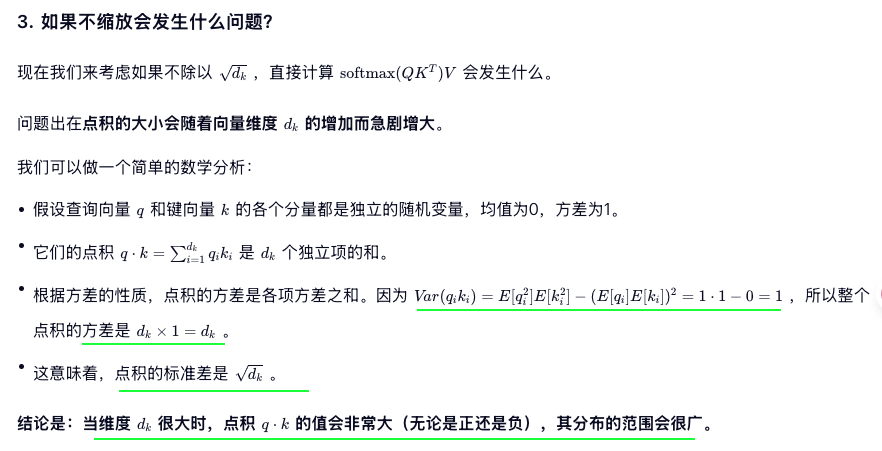

In [3]:
Image(filename='./d_k.png')

In [ ]:
这对 softmax 函数会产生灾难性的影响。让我们看看 softmax 函数的图像：

     y
     ^
     |         /-------
   1 +        /
     |       /
     |      /
-----+-----/--------------> x
     |    /
     |   /
   0 +--/
     |

- 当输入x变得非常大（正值）时，softmax(x)的输出会趋近于1
- 当输入x变得非常小（负值）时，softmax(x)的输出会趋近于0

<b>如果 QK^T中的值因为维度高而变得非常大，那么经过 softmax 之后，结果会变成一个one-hot形式的向量</b>：其中一个位置的权重接近1，而其他所有位置的权重都接近0。

这种情况被称为 <b>softmax 饱和（softmax saturation）</b>

#### 饱和带来的问题：梯度消失

在神经网络的反向传播训练中，我们需要计算损失函数对模型参数的梯度。<b>如果 softmax 的输出已经饱和（接近0或1），那么它的梯度会变得非常小，甚至接近于零。</b>

- <b>Softmax 函数的导数在输入值很大时会趋近于0。</b>
- 如果注意力权重已经是 one-hot 形式，模型就失去了“柔性”，它几乎只关注一个位置，而完全忽略了其他位置的信息。
- 更重要的是，由于梯度极小，模型参数在反向传播时几乎得不到更新，导致训练过程变得非常缓慢甚至停滞。这就是著名的梯度消失问题。

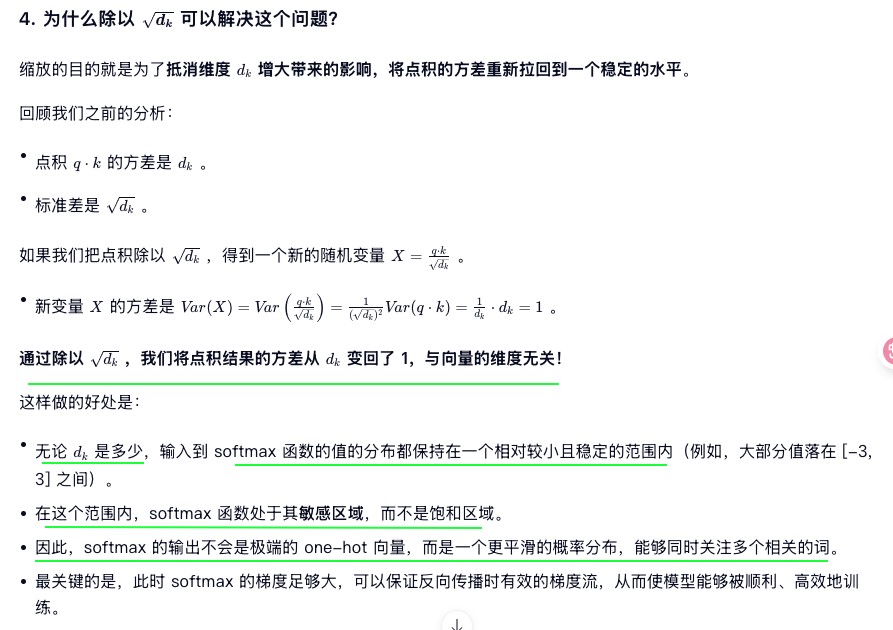

In [4]:
Image(filename='./why_d_k.png')

## 注意力机制中的点积
- 注意力机制的核心是查询（Query）与（Key）的点积：

In [ ]:
def scaled_dot_product_attention(Q,K,V):
    '''
    缩放点积注意力
    attention（Q,K,V） = softmax（Q @ K^T / sqrt(d_k)）@ V
    
    sqrt(d_k)：缩放因子，防止点积过大导致softmax梯度消失：
    - 当d_k较大时，点积的方差会增大
    - 导致softmax进入饱和区（梯度极小）
    - 缩放保持方差稳定，训练更稳定
    
    是为了防止在高维空间中，查询向量 (Q) 和键向量 (K) 的点积结果过大，
    导致后续的 softmax 函数进入饱和区。一旦饱和，会引起梯度消失，使得模型难以训练。
    通过除以 d_k可以将点积的方差标准化为1，确保 softmax 始终工作在其梯度敏感的线性区域，
    从而保证模型的稳定和优化效率。
    
    '''
    
    # 1.获取维度
    d_k = Q.size(-1) # Q和K的最后一维应该相同
    
    # 2.计算注意力分数（点积）
    '''
    Q：[batch,seq_len,d_k]
    K：[batch,seq_len,d_k]
    scores：[batch,seq_len_q,seq_len_k]
    '''
    scores = torch.matmul(Q,k.transpose(-2,-1))/math.sqrt(d_k)
    
    # 3.应用softmax获取注意力权重
    attention_weights = torch.softmax(scores,dim=-1)
    
    # 4.加权求和
    output = torch.matmul(attention_weights,V)
    return output

batch_size = 2
seq_len = 3
d_k = 4

Q = torch.randn(batch_size,seq_len,d_k)
K = torch.randn(batch_size,seq_len,d_k)
V = torch.randn(batch_size,seq_len,d_k)

attention_output = scaled_dot_product_attention(Q,K,V)
print(f"Attention输出形状：{attention_output.shape}")

## 全连接层中的矩阵乘法